In [ ]:
!pip install kaggle --quiet
import os, json
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import scipy.stats as stats
import random

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
with open("/content/drive/MyDrive/MatApl/Ayudantías/26-1 Ayudantias/Redes Complejas/Clases/kaggle_key.json", "r") as f:
    cred = json.load(f)

os.environ["KAGGLE_USERNAME"] = cred["username"]
os.environ["KAGGLE_KEY"] = cred["key"]

In [ ]:
!kaggle datasets download -d stackoverflow/stack-overflow-tag-network -p /content --unzip

Dataset URL: https://www.kaggle.com/datasets/stackoverflow/stack-overflow-tag-network
License(s): CC-BY-SA-3.0
100% 6.72k/6.72k [00:00<00:00, 18.8MB/s]



# ¿Cómo los desarrolladores las combinan en sus perfiles profesionales en Stack Overflow? Base de datos de [kaggle](https://www.kaggle.com/datasets/stackoverflow/stack-overflow-tag-network/data)

In [ ]:
stack_overflow_nodes = pd.read_csv('/content/stack_network_nodes.csv')
stack_overflow_edges = pd.read_csv('/content/stack_network_links.csv')

In [ ]:
G = nx.from_pandas_edgelist(stack_overflow_edges, source='source', target='target', edge_attr='value', create_using=nx.Graph())

# Add node attributes
for index, row in stack_overflow_nodes.iterrows():
    node_name = row['name']
    if node_name in G:
        G.nodes[node_name]['group'] = row['group']
        G.nodes[node_name]['nodesize'] = row['nodesize']

print(f"Número de nodos: {G.number_of_nodes()}")
print(f"Número de enlaces: {G.number_of_edges()}")

Número de nodos: 115
Número de enlaces: 245


In [ ]:
stack_overflow_nodes

,name,group,nodesize
0,html,6,272.45
1,css,6,341.17
2,hibernate,8,29.83
3,spring,8,52.84
4,ruby,3,70.14
...,...,...,...
110,perl,13,19.38
111,cloud,9,10.66
112,photoshop,6,12.62
113,powershell,5,9.85


El valor de los enlaces indica que tan seguido dos tecnologías aparecen en un perfil relativo a cuantas veces aparecen por separado. Qué tan más probable es que dos tecnologías aparezcan juntas comparado con si fueran independientes.

In [ ]:
stack_overflow_edges

,source,target,value
0,azure,.net,20.933192
1,sql-server,.net,32.322524
2,asp.net,.net,48.407030
3,entity-framework,.net,24.370903
4,wpf,.net,32.350925
...,...,...,...
485,objective-c,xcode,43.418825
486,swift,xcode,48.620335
487,iphone,xcode,34.712865
488,ios,xcode,46.365091


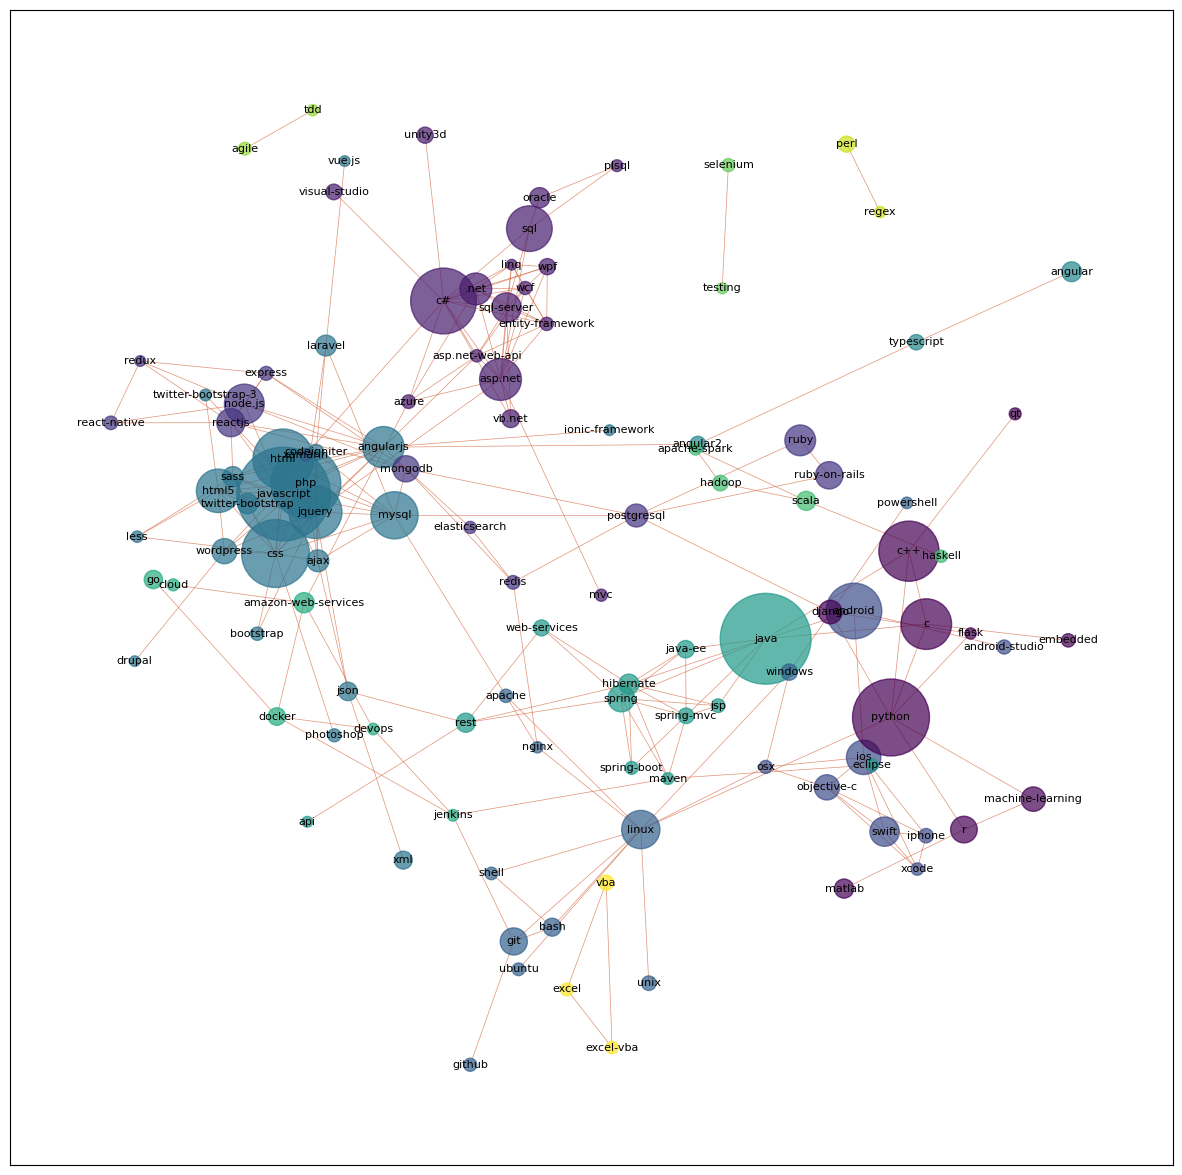

In [ ]:

plt.figure(figsize=(15, 15))

pos = nx.spring_layout(G, k=0.15, iterations=20)

node_size = [G.nodes[node]['nodesize'] * 7 for node in G.nodes()]
node_color = [G.nodes[node]['group'] for node in G.nodes()]

node_collection = nx.draw_networkx_nodes(
    G,
    pos=pos,
    node_size=node_size,
    node_color=node_color,
    cmap=plt.cm.viridis,
    alpha=0.7
)

nx.draw_networkx_edges(
    G,
    pos=pos,
    width=0.5,
    alpha=0.7,
    edge_color='#d3643b'
)

nx.draw_networkx_labels(
    G,
    pos=pos,
    font_size=8
)
plt.show()

# Métricas

In [ ]:
#Verificamos si el grafo es conexo, por Closeness y Diámetro
#solo están bien definidos dentro de una misma componente conexa
#(si dos nodos no tienen camino entre sí, la distancia es infinita.

print("¿Es conexo?:", nx.is_connected(G))
print("Cantidad de componentes conexas:", nx.number_connected_components(G))

if not nx.is_connected(G):
    componentes = list(nx.connected_components(G))
    nodos_lcc = max(componentes, key=len)
    G_metricas = G.subgraph(nodos_lcc).copy()
    print(f"Se usará la componente más grande ({G_metricas.number_of_nodes()} "
          f"de {G.number_of_nodes()} nodos) para Closeness y Diámetro.")
else:
    G_metricas = G

¿Es conexo?: False
Cantidad de componentes conexas: 6
Se usará la componente más grande (102 de 115 nodos) para Closeness y Diámetro.


In [ ]:
#Centralidades

degree_centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G, weight="value")
eigenvector = nx.eigenvector_centrality(G, weight="value", max_iter=1000)
katz = nx.katz_centrality_numpy(G, alpha=0.005, beta=1.0, weight="value")
clustering = nx.clustering(G.to_undirected(), weight="value")

G_metricas_dist = G_metricas.copy()
for u, v, d in G_metricas_dist.edges(data=True):
    d["distancia"] = 1 / d["value"] if d["value"] > 0 else float("inf")
closeness = nx.closeness_centrality(G_metricas_dist, distance="distancia")

pagerank = nx.pagerank(G, weight="value")
densidad = nx.density(G)
transitividad = nx.transitivity(G)

diametro = nx.diameter(G_metricas_dist, weight="distancia")       #ponderado
diametro_saltos = nx.diameter(G_metricas)                         #cantidad de saltos


def sort_dict_desc(d):
    return dict(sorted(d.items(), key=lambda x: x[1], reverse=True))

degree_centrality_sorted = sort_dict_desc(degree_centrality)
betweenness_sorted = sort_dict_desc(betweenness)
eigenvector_sorted = sort_dict_desc(eigenvector)
katz_sorted = sort_dict_desc(katz)
clustering_sorted = sort_dict_desc(clustering)
closeness_sorted = sort_dict_desc(closeness)
pagerank_sorted = sort_dict_desc(pagerank)


def print_top(metric_name, metric_dict, top_n=10):
    print(f"\n Top {top_n} - {metric_name}")
    for i, (node, value) in enumerate(list(metric_dict.items())[:top_n], 1):
        print(f"{i}. {node}: {value:.6f}")


print_top("Degree Centrality", degree_centrality_sorted)
print_top("Betweenness Centrality", betweenness_sorted)
print_top("Eigenvector Centrality", eigenvector_sorted)
print_top("Katz Centrality", katz_sorted)
print_top("Clustering Coefficient", clustering_sorted)
print_top("Closeness Centrality", closeness_sorted)
print_top("PageRank", pagerank_sorted)

print(f"\nDensidad de la red: {densidad:.6f}")
print(f"Transitividad (clustering global): {transitividad:.6f}")
print(f"Diámetro (ponderado por distancia): {diametro:.6f}")
print(f"Diámetro (cantidad de saltos, sin pesos): {diametro_saltos}")


 Top 10 - Degree Centrality
1. jquery: 0.140351
2. c#: 0.122807
3. css: 0.122807
4. asp.net: 0.114035
5. angularjs: 0.114035
6. javascript: 0.105263
7. mysql: 0.096491
8. php: 0.087719
9. html5: 0.087719
10. linux: 0.087719

 Top 10 - Betweenness Centrality
1. linux: 0.242198
2. mysql: 0.180717
3. jquery: 0.180252
4. angularjs: 0.178544
5. apache: 0.127620
6. json: 0.118770
7. python: 0.117063
8. rest: 0.108213
9. asp.net: 0.105884
10. asp.net-web-api: 0.099053

 Top 10 - Eigenvector Centrality
1. css: 0.464730
2. jquery: 0.372922
3. javascript: 0.369572
4. html: 0.330424
5. php: 0.307983
6. html5: 0.287805
7. mysql: 0.195934
8. sass: 0.186034
9. angularjs: 0.170496
10. ajax: 0.157253

 Top 10 - Katz Centrality
1. node.js: 0.474494
2. reactjs: 0.450781
3. express: 0.363195
4. mongodb: 0.344091
5. angularjs: 0.280445
6. redux: 0.274682
7. react-native: 0.230180
8. redis: 0.078379
9. javascript: 0.065917
10. postgresql: 0.053660

 Top 10 - Clustering Coefficient
1. swift: 0.450424
2. sp

# Asortatividad


Si r > 0

Los nodos tienden a conectarse con otros del mismo grupo. → Ecosistemas cerrados.

Si r ≈ 0

No hay patrón estructural claro.

Si r < 0

Los nodos tienden a conectarse con nodos de grupos distintos.

In [ ]:
#Asortatividad por grupo (¿los nodos tienden a conectarse con otros del mismo grupo?)
assortativity = nx.attribute_assortativity_coefficient(G, "group")

print("Asortatividad por grupo:", assortativity)

Asortatividad por grupo: 0.8770734448536422


Los puentes indican herramientas que se utilizan en dos o más roles, por ejemplo, python para backend y python para data analysis.

In [ ]:
bridges = list(nx.bridges(G.to_undirected()))

count = {}

for i, j in bridges:
    if i in count:
        count[i] += 1
    else:
        count[i] = 1

    if j in count:
        count[j] += 1
    else:
        count[j] = 1

count_sorted = dict(sorted(count.items(), key=lambda x: x[1], reverse=True))
count_sorted


{'c#': 3,
 'typescript': 2,
 'angular2': 2,
 'angularjs': 2,
 'linux': 2,
 'asp.net': 1,
 'mvc': 1,
 'xamarin': 1,
 'unity3d': 1,
 'visual-studio': 1,
 'tdd': 1,
 'agile': 1,
 'css': 1,
 'photoshop': 1,
 'json': 1,
 'xml': 1,
 'cloud': 1,
 'amazon-web-services': 1,
 'docker': 1,
 'go': 1,
 'android': 1,
 'android-studio': 1,
 'angular': 1,
 'ionic-framework': 1,
 'unix': 1,
 'ubuntu': 1,
 'scala': 1,
 'haskell': 1,
 'rest': 1,
 'api': 1,
 'git': 1,
 'github': 1,
 'c++': 1,
 'qt': 1,
 'c': 1,
 'embedded': 1,
 'laravel': 1,
 'vue.js': 1,
 'wordpress': 1,
 'drupal': 1,
 'maven': 1,
 'eclipse': 1,
 'windows': 1,
 'powershell': 1,
 'r': 1,
 'matlab': 1,
 'regex': 1,
 'perl': 1,
 'testing': 1,
 'selenium': 1}

# Distribución de grados

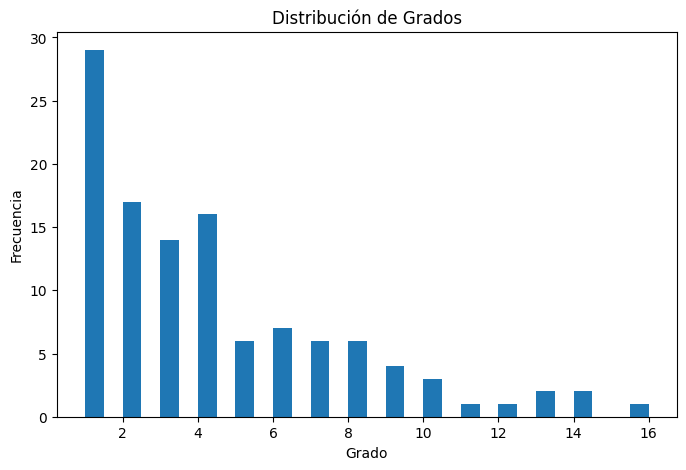

In [ ]:
degrees = [deg for node, deg in G.degree()]

plt.figure(figsize=(8,5))
plt.hist(degrees, bins=30)
plt.title("Distribución de Grados")
plt.xlabel("Grado")
plt.ylabel("Frecuencia")
plt.show()

# Vistas

In [ ]:
G = nx.Graph()

#Nodos con atributos
for _, row in stack_overflow_nodes.iterrows():
    G.add_node(
        row["name"],
        group=row["group"], #Atributo #1
        nodesize=row["nodesize"] #Atributo #2
    )

#Enlaces con peso del dataframe
for _, row in stack_overflow_edges.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        weight=int(round(row["value"]))
    )

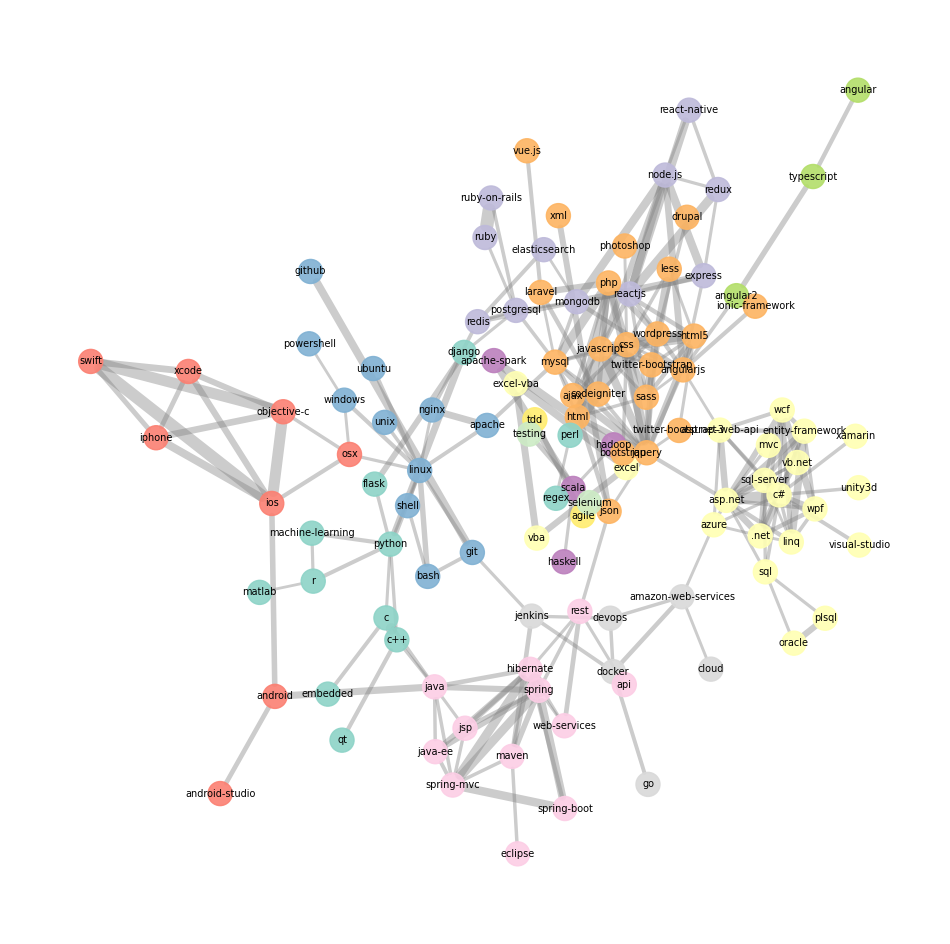

In [ ]:
plt.figure(figsize=(12,12))

pos = nx.kamada_kawai_layout(G)

# Colores por grupo
groups = nx.get_node_attributes(G, "group")
unique_groups = list(set(groups.values()))
cmap = plt.get_cmap("Set3")
color_map = {g: cmap(i % cmap.N) for i, g in enumerate(unique_groups)}
node_colors = [color_map[groups[n]] for n in G.nodes()]

# Grosor aristas proporcional al peso
weights = [G[u][v]["weight"] for u,v in G.edges()]
edge_widths = [w * 0.1 for w in weights]

nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    alpha=0.9
)

nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    alpha=0.4,
    edge_color="gray",
    arrows=True
)

nx.draw_networkx_labels(
    G, pos,
    font_size=7, # Adjusted font size for readability
    font_color='black'
)

plt.axis("off")
plt.show()


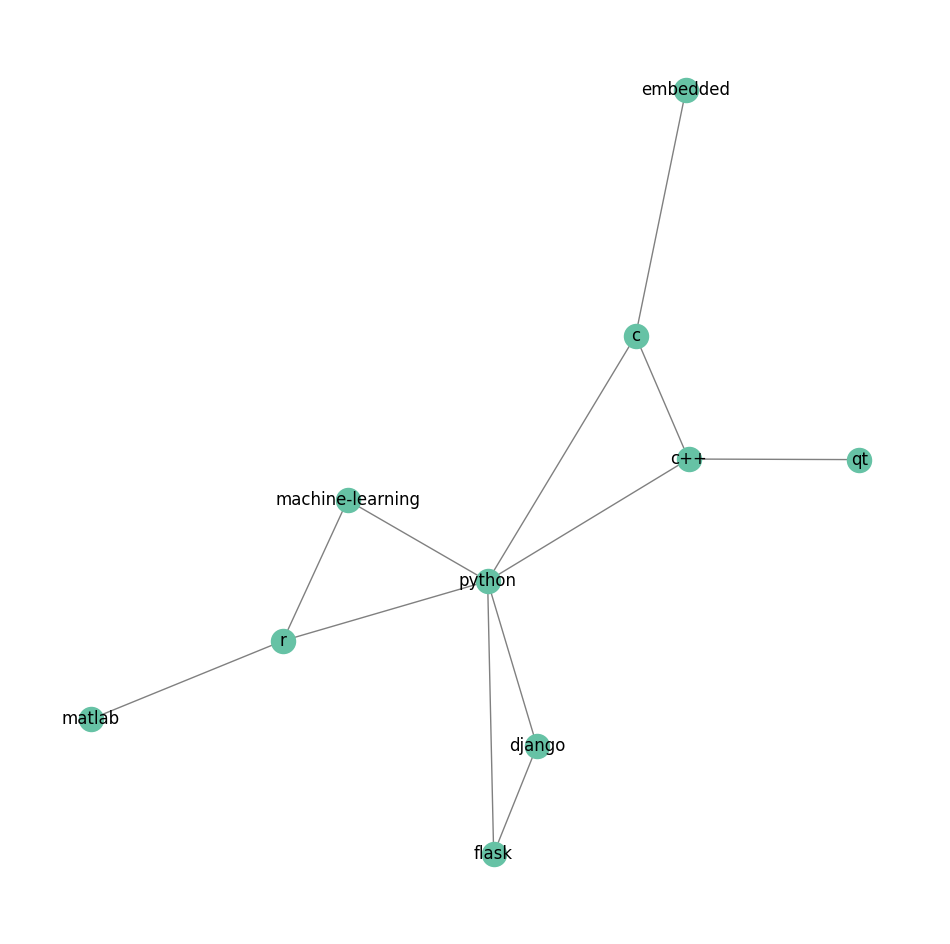

In [ ]:
from networkx.classes.graphviews import subgraph_view

def filter_nodes(n):
    return G.nodes[n]["group"] == 1

G_sub = subgraph_view(G, filter_node=filter_nodes)

plt.figure(figsize=(12, 12))
pos_sub = nx.spring_layout(G_sub, seed=42)

nx.draw_networkx(
    G_sub,
    pos=pos_sub,
    node_color="#66c2a5",
    node_size=300,
    edge_color="gray",
    arrows=True
)

plt.axis("off")
plt.show()